# Lentils × Dinomaly: inference + per-class AUROC

Load a pipeline trained by one of the `lentils_*_train_tutorial.ipynb` notebooks, run it over
the **180-frame test split**, and report:

- **overall pixel + image AUROC** (binary anomaly = any foreign object), and
- a **per-class pixel AUROC** breakdown across the 8 COCO categories, using the baked
  `class_mask` (one-vs-background per class).

> **Prerequisites**
>
> 1. Install cuvis-ai-dinomaly with the examples extra: `uv sync --extra examples`.
> 2. From the repo root, launch the notebook with `uv run jupyter lab`.
> 3. Train + save a pipeline first (run `lentils_rgb_train_tutorial.ipynb`, or the CIR /
>    adaclip-bands siblings). This notebook loads it from `PIPELINE_DIR` (set in the configuration
>    cell; defaults to the RGB run's `outputs/lentils_rgb_run/trained_models`). Edit it to evaluate
>    a different run.
>
> **Data**: `prepare_lentils_data` downloads + converts the dataset to per-frame NPZ under
> `outputs/npz_local` (reused if a train notebook already produced it there), writing a
> `universe.csv` + `splits.json`; the 180-frame test split is resolved from the splits.json.
> `TEST_LIMIT` (0 = full 180; N = first N frames) and `SMOKE_LIMIT` (frames per split when
> converting) are set in the configuration cell.

In [1]:
# Colab bootstrap: no-op when running locally
try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("In Colab Env")
    %pip install -q cuvis-ai cuvis-ai-dinomaly "cuvis-ai-dataloader[cu3s,coco]"

    import torch

    if not torch.cuda.is_available():
        print(
            "WARNING: No GPU detected. Switch via Runtime > Change runtime type > T4 GPU. "
            "Dinomaly inference on CPU is slow."
        )

In [2]:
%matplotlib inline
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import utils
from cuvis_ai_core.pipeline.pipeline import CuvisPipeline
from cuvis_ai_core.training import Predictor
from cuvis_ai_core.utils.node_registry import NodeRegistry
from cuvis_ai_dataloader.data import MultiNpzDataModule
from cuvis_ai_dinomaly.node.per_class_auroc import PerClassAnomalyAUROC
from cuvis_ai_schemas.enums import ExecutionStage
from cuvis_ai_schemas.training import DataSplitConfig
from loguru import logger
from utils import LENTILS_CATEGORIES, prepare_lentils_data, resolve_config, resolve_pipeline

W0716 10:23:30.699000 30888 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


In [3]:
# Keep the notebook output readable: log at INFO and above. Nodes emit per-step progress
# (e.g. the TensorBoard monitor) at DEBUG, a firehose across the whole test pass; raise the
# floor to INFO here.
logger.remove()
logger.add(sys.stderr, level="INFO")

device = torch.device("cpu")
# Pick the best available torch device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
logger.info(f"Using device {device}")

2026-07-16 10:23:31.050 | INFO     | __main__:<module>:13 - Using device cuda


## Tutorial configuration

Edit these variables to choose what to evaluate and how much.

- **`PIPELINE_DIR`**: a train notebook's `trained_models` dir. Defaults to the RGB run
  (`outputs/lentils_rgb_run/trained_models`); point it at a CIR or AdaCLIP-bands run to compare
  front-ends on the identical test set.
- **`TEST_LIMIT`**: 0 evaluates the full 180-frame test split; N evaluates the first N frames.
- **`SMOKE_LIMIT`**: 0 converts all frames; N caps frames per split when preparing the NPZ (a
  fast dry-run when the data is not yet on disk).

In [4]:
# --- Which trained run to evaluate + how much (edit these) ---------------
PIPELINE_DIR = Path("outputs/lentils_rgb_run/trained_models")  # a train notebook's output dir
TEST_LIMIT = 0  # 0 = full 180-frame test split; N = first N frames
SMOKE_LIMIT = 0  # 0 = all frames; N = N per split when converting

config = resolve_config()
PIPE_YAML, PIPE_PT = resolve_pipeline(PIPELINE_DIR)

print(f"Pipeline dir:  {PIPELINE_DIR}")
print(f"Pipeline YAML: {PIPE_YAML}")
print(f"Weights:       {PIPE_PT} ({PIPE_PT.stat().st_size / 1e6:.0f} MB)")
print(f"Test limit:    {TEST_LIMIT or 'full (180)'}")

Pipeline dir:  outputs\lentils_rgb_run\trained_models
Pipeline YAML: outputs\lentils_rgb_run\trained_models\dinomaly_lentils_rgb_restored.yaml
Weights:       outputs\lentils_rgb_run\trained_models\dinomaly_lentils_rgb_restored.pt (592 MB)
Test limit:    full (180)


## 1 · Load the trained pipeline

Register the Dinomaly plugin (so the saved node classes resolve), then
`CuvisPipeline.load_pipeline` rebuilds the graph and loads the weights.

In [5]:
registry = NodeRegistry()
registry.register_plugin(str(config["plugins_yaml"]))
pipeline = CuvisPipeline.load_pipeline(
    str(PIPE_YAML), weights_path=str(PIPE_PT), device=str(device), node_registry=registry
)
pipeline.torch_layers.eval()
print("Loaded:", pipeline.name, "| nodes:", [n.name for n in pipeline.nodes])

# Attach an eval-only per-class AUROC metric node. It reads the detector's `scores` and the data
# node's `class_mask` port and accumulates a one-vs-background pixel AUROC per class during the pass;
# section 4 reads the result straight off the node, exactly like the overall metrics in section 3.
by_name = {n.name: n for n in pipeline.nodes}
per_class_metric = PerClassAnomalyAUROC(name="metrics_perclass", class_names=LENTILS_CATEGORIES)
pipeline.connect(by_name["dinomaly_detector"].outputs.scores, per_class_metric.inputs.scores)
pipeline.connect(by_name["anomaly_data"].outputs.class_mask, per_class_metric.inputs.class_mask)
per_class_metric.to(device)

SPLITS_JSON, UNIVERSE_CSV = prepare_lentils_data(
    Path("outputs/npz_local"),
    dataset_dir=Path("/content/data") if IN_COLAB else None,
    limit=SMOKE_LIMIT,
)
datamodule = MultiNpzDataModule(
    splits=DataSplitConfig(splits_path=str(SPLITS_JSON.resolve())),
    universe_csv=str(UNIVERSE_CSV),
    batch_size=1,
    num_workers=0,
)
datamodule.setup(stage="predict")  # Predictor evaluates the predict split (a copy of test)
print("Predict (= test) frames:", len(datamodule.predict_ds))

2026-07-16 10:23:31.273 | INFO     | cuvis_ai_core.utils.node_registry:register_plugins_installed:534 - Loaded preinstalled plugin 'dinomaly' with 4 nodes


2026-07-16 10:23:31.274 | INFO     | cuvis_ai_core.utils.node_registry:register_plugin:380 - Registered plugin 'dinomaly' from D:\code-repos\cuvis-ai-dinomaly\cuvis-ai-dinomaly\examples\plugins.yaml


2026-07-16 10:23:32.980 | WARNING  | cuvis_ai.node.monitor:_resolve_log_dir:141 - Run directory 'dinomaly_lentils_rgb' already exists. Using 'dinomaly_lentils_rgb_v19' instead.


2026-07-16 10:23:32.982 | INFO     | cuvis_ai.node.monitor:__init__:117 - TensorBoard writer initialized: outputs\lentils_rgb_run\tensorboard\dinomaly_lentils_rgb_v19


2026-07-16 10:23:32.982 | INFO     | cuvis_ai.node.monitor:__init__:118 - To view visualizations, run: uv run tensorboard --logdir=outputs\lentils_rgb_run\tensorboard


Loaded: dinomaly_lentils_rgb | nodes: ['anomaly_data', 'MinMaxNormalizer', 'rgb_selector', 'dinomaly_detector', 'dinomaly_train_loss', 'decider', 'metrics_anomaly', 'TensorBoardMonitorNode', 'metrics_auroc']


Predict (= test) frames: 180


### Pipeline graph

Inline view of the restored graph. A `CuvisPipeline` renders itself in Jupyter as an
inline SVG, rendered from Graphviz DOT in memory (needs the system `dot` binary; it falls
back to a Mermaid source block otherwise).

In [6]:
pipeline

dinomaly_lentils_rgb:
AnomalyDataNode(
  (_binary_mapper): BinaryAnomalyLabelMapper()
)
MinMaxNormalizer()
FixedWavelengthSelector()
DinomalyDetector(
  (dinomaly_model): DinomalyModel(
    (encoder): DinoVisionTransformer(
      (patch_embed): PatchEmbed(
        (proj): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
        (norm): Identity()
      )
      (blocks): ModuleList(
        (0-11): 12 x Block(
          (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (attn): MemEffAttention(
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (q_norm): Identity()
            (k_norm): Identity()
            (attn_drop): Dropout(p=0.0, inplace=False)
            (norm): Identity()
            (proj): Linear(in_features=768, out_features=768, bias=True)
            (proj_drop): Dropout(p=0.0, inplace=False)
          )
          (ls1): LayerScale()
          (drop_path1): Identity()
          (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
          (mlp): DinomalyMLP(
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (act): GELU(approximate='none')
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
            (drop): Dropout(p=0.0, inplace=False)
          )
          (ls2): LayerScale()
          (drop_path2): Identity()
        )
      )
      (norm): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (head): Identity()
    )
    (bottleneck): ModuleList(
      (0): DinomalyMLP(
        (fc1): Linear(in_features=768, out_features=3072, bias=False)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=3072, out_features=768, bias=False)
        (drop): Dropout(p=0.2, inplace=False)
      )
    )
    (decoder): ModuleList(
      (0-7): 8 x DecoderViTBlock(
        (norm1): LayerNorm((768,), eps=1e-08, elementwise_affine=True)
        (attn): LinearAttention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (drop_path): Identity()
        (norm2): LayerNorm((768,), eps=1e-08, elementwise_affine=True)
        (mlp): DinomalyMLP(
          (fc1): Linear(in_features=768, out_features=3072, bias=False)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=3072, out_features=768, bias=False)
          (drop): Dropout(p=0.0, inplace=False)
        )
      )
    )
    (gaussian_blur): GaussianBlur2d()
    (loss_fn): CosineHardMiningLoss()
  )
  (_preprocess): Compose(
        Resize(size=[448, 448], interpolation=InterpolationMode.BILINEAR, antialias=True)
        Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], inplace=False)
  )
)
DinomalyTrainLossBridge()
QuantileBinaryDecider()
AnomalyDetectionMetrics(
  (precision_metric): BinaryPrecision()
  (recall_metric): BinaryRecall()
  (f1_metric): BinaryF1Score()
  (iou_metric): BinaryJaccardIndex()
  (average_precision_metric): BinaryAveragePrecision()
)
TensorBoardMonitorNode()
AnomalyAUROCMetrics(
  (pixel_auroc): BinaryAUROC()
  (image_auroc): BinaryAUROC()
)
PerClassAnomalyAUROC(
  (_aurocs): ModuleDict(
    (1): BinaryAUROC()
    (2): BinaryAUROC()
    (3): BinaryAUROC()
    (4): BinaryAUROC()
    (5): BinaryAUROC()
    (6): BinaryAUROC()
    (7): BinaryAUROC()
  )
)
Use `pipeline.visualize()` for Graphviz/Mermaid output.

## 2 · Run inference on the test split

`Predictor` runs the loaded pipeline over the split, so there is no hand-rolled forward loop. With
`stage=ExecutionStage.TEST` the pipeline's metric nodes fire: the overall metrics (section 3) and the
per-class node attached above both accumulate during this single pass. `collect_ports` keeps a few
per-frame outputs (anomaly map, binary mask, per-frame score), moved to CPU, for the qualitative
panels in section 5; `utils.panel_frames` flattens them into one record per frame. The DINOv2
encoder runs under `torch.no_grad()` inside `Predictor`.

In [7]:
collected = Predictor(pipeline, datamodule).predict(
    stage=ExecutionStage.TEST,
    collect_outputs=True,
    max_batches=(TEST_LIMIT or None),
    collect_ports={"scores", "mask", "anomaly_score"},
)
frames = utils.panel_frames(collected, datamodule)
n_anom = sum(1 for f in frames if f["is_anomalous"])
print(f"{len(frames)} frames evaluated | {n_anom} anomalous, {len(frames) - n_anom} normal")

Predict [dinomaly_lentils_rgb]:   0%|          | 0/180 [00:00<?, ?batch/s]

Predict [dinomaly_lentils_rgb]:   1%|          | 1/180 [00:02<06:00,  2.01s/batch]

Predict [dinomaly_lentils_rgb]:   1%|          | 2/180 [00:03<04:37,  1.56s/batch]

Predict [dinomaly_lentils_rgb]:   2%|▏         | 3/180 [00:04<04:01,  1.36s/batch]

Predict [dinomaly_lentils_rgb]:   2%|▏         | 4/180 [00:05<03:37,  1.24s/batch]

...

Predict [dinomaly_lentils_rgb]:  99%|█████████▉| 178/180 [03:20<00:02,  1.10s/batch]

Predict [dinomaly_lentils_rgb]:  99%|█████████▉| 179/180 [03:21<00:01,  1.10s/batch]

Predict [dinomaly_lentils_rgb]: 100%|██████████| 180/180 [03:22<00:00,  1.08s/batch]

Predict [dinomaly_lentils_rgb]: 100%|██████████| 180/180 [03:22<00:00,  1.13s/batch]

180 frames evaluated | 112 anomalous, 68 normal


## 3 · Overall metrics

Read straight off the pipeline's metric nodes, which accumulated during the `Predictor` pass above:
`metrics_auroc` (`AnomalyAUROCMetrics`) gives pixel + image AUROC, and `metrics_anomaly`
(`AnomalyDetectionMetrics`) gives IoU / F1 / average precision on the binarized map. The AUROC node
is histogram-binned at its `thresholds`, a close approximation to the exact pooled AUROC.

In [8]:
by_name = {n.name: n for n in pipeline.nodes}
auroc, anomaly = by_name["metrics_auroc"], by_name["metrics_anomaly"]
print(f"pixel_auroc       : {float(auroc.pixel_auroc.compute()):.4f}")
print(f"image_auroc       : {float(auroc.image_auroc.compute()):.4f}")
print(f"iou               : {float(anomaly.iou_metric.compute()):.4f}")
print(f"f1                : {float(anomaly.f1_metric.compute()):.4f}")
print(f"average_precision : {float(anomaly.average_precision_metric.compute()):.4f}")

pixel_auroc       : 0.9309
image_auroc       : 0.6549
iou               : 0.1058
f1                : 0.1913
average_precision : 0.2380


## 4 · Per-class pixel AUROC

Read off the `metrics_perclass` node, which accumulated a one-vs-background pixel AUROC per class
during the pass above (this class's pixels as positives, background as negatives). Like the AUROC in
section 3 it is histogram-binned. Classes absent from the evaluated frames are skipped.

fly          0.8621
stone        0.8647
rubber       0.8654
alu_shard    0.9067
white_paper  0.9829
stem_k       0.9937
blue_paper   0.9988


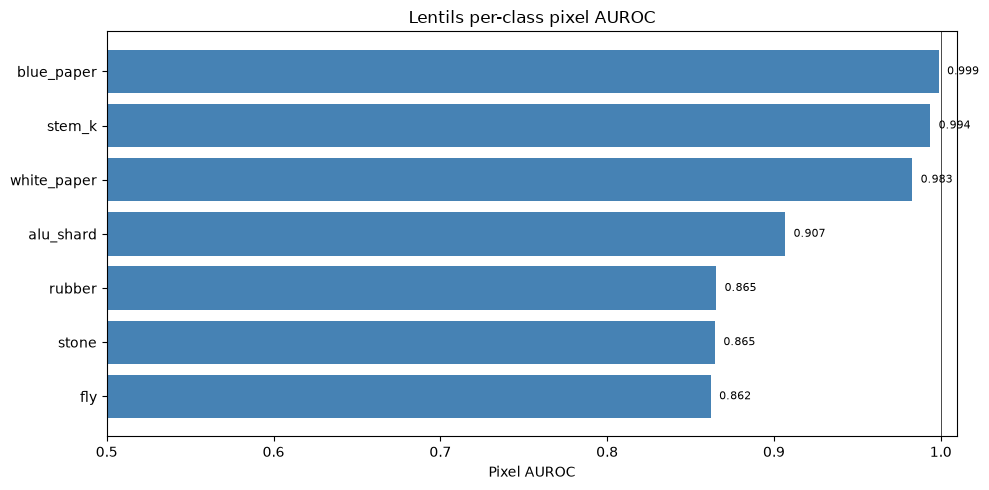

In [9]:
metrics_perclass = {n.name: n for n in pipeline.nodes}["metrics_perclass"]
per_class = metrics_perclass.compute()
for name, v in sorted(per_class.items(), key=lambda kv: kv[1]):
    print(f"{name:12s} {v:.4f}")
if per_class:
    utils.plot_per_class_auroc_bar(per_class, title="Lentils per-class pixel AUROC")
    plt.show()
else:
    print("(no non-background classes present in the evaluated frames)")

## 5 · Qualitative panels

A few anomalous frames: false-color scene, anomaly heatmap, and the scene with the
ground-truth contour overlaid. Cubes are reloaded from their NPZ for a true false-color view.

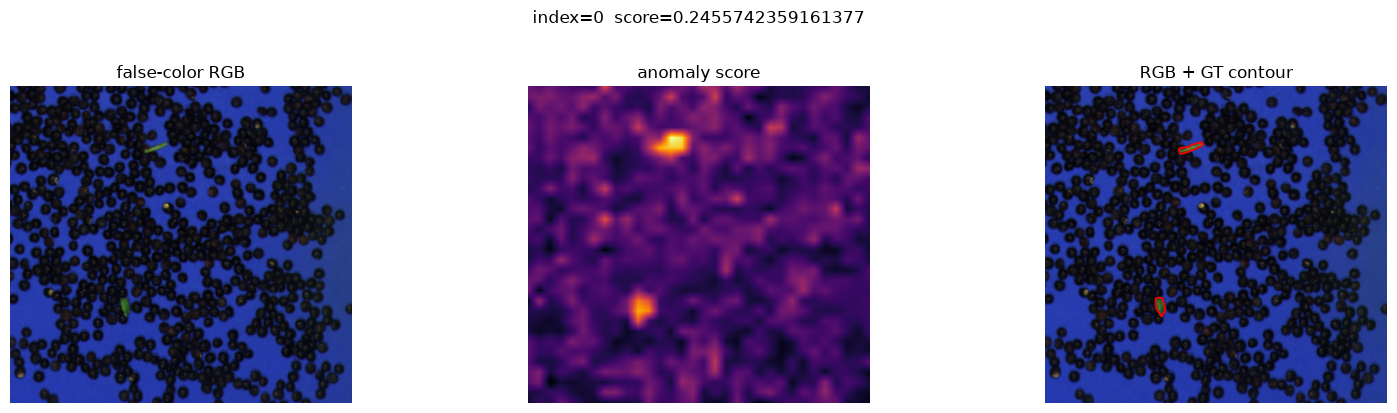

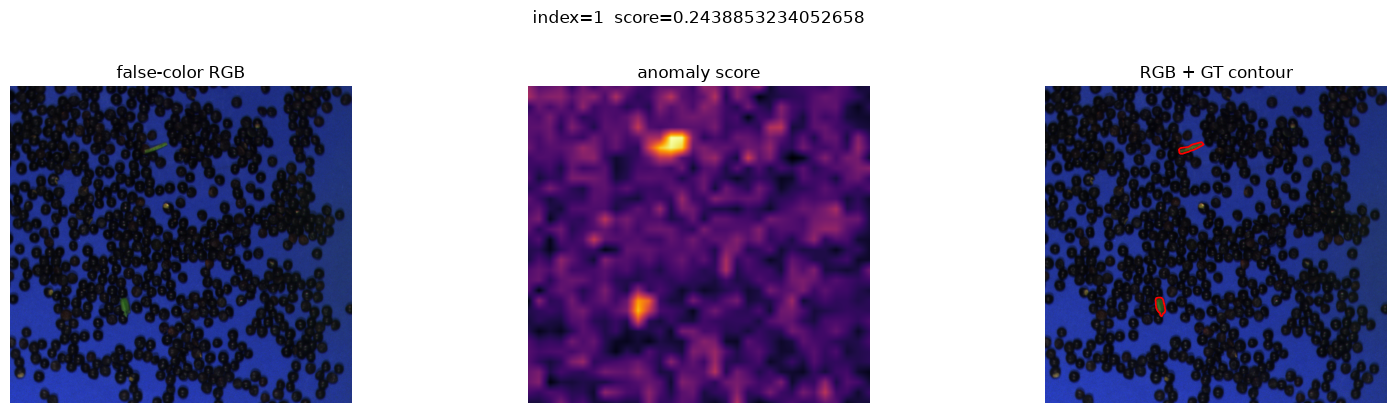

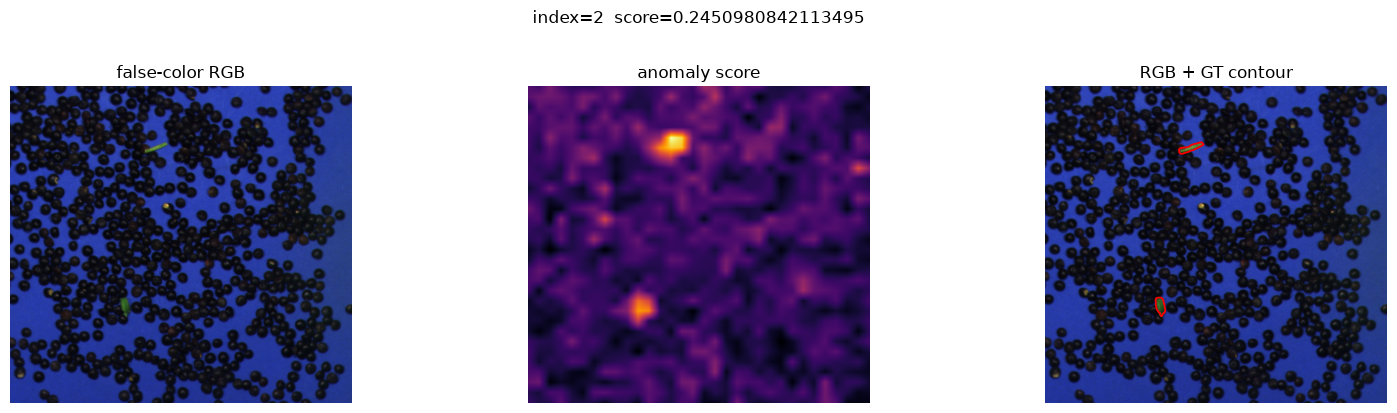

In [10]:
anom = [f for f in frames if f["is_anomalous"]][:3]
for f in anom:
    fr = utils.load_lentils_frame(f["path"])
    cube, wl = fr["cube"], fr["wavelengths"]
    title = f"index={f['index']}  score={f['anomaly_score']}"
    utils.render_inference_panel(
        cube if cube.ndim == 3 else cube[0],
        f["score_map"],
        wavelengths=wl,
        gt_mask=f["mask"],
        title=title,
    )
    plt.show()

## Takeaways

- Numbers come from *your* trained pipeline: a 1-epoch smoke will look weak. For a real
  result, set `MAX_EPOCHS = 20` (or 50) in section 3 of `lentils_rgb_train_tutorial.ipynb`
  and rerun from section 6 (or launch the same run with `uv run restore-trainrun`).
- Per-class AUROC surfaces which foreign-object types Dinomaly separates best from normal
  lentils, useful for deciding where a supervised head would add the most.
- To compare front-ends, point `PIPELINE_DIR` (setup cell) at a CIR or AdaCLIP-bands run's
  `trained_models` dir and rerun on the identical test set.